# **LOS/NLOS Classifier Model**

## **Project Setup**
### **Import libraries**

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

## **Data Preparation**
### **Load data**
Load all 7 datasets csv files into a single dataframe

In [60]:
dataset_path = "../dataset/"  # Dataset directory

csv_files = [
    f for f in os.listdir(dataset_path) if f.endswith(".csv")
]  # Retrieve all csv files in the dataset folder

print(csv_files)  # print out all the csv file name in the 'dataset' folder

# Load and print out dataset values
dfs = []
for file in csv_files:
    print(f"Reading file: {file}")  # Print the file name being read
    df_temp = pd.read_csv(os.path.join(dataset_path, file))  # Read the CSV file
    # print(df_temp)  # Print the entire data of the current CSV file
    dfs.append(df_temp)  # Append the DataFrame to the list

df = pd.concat(
    dfs, ignore_index=True
)  # combining all datasets (csv) files into one DataFrame
print(df)

['uwb_dataset_part2.csv', 'uwb_dataset_part3.csv', 'uwb_dataset_part1.csv', 'uwb_dataset_part4.csv', 'uwb_dataset_part5.csv', 'uwb_dataset_part7.csv', 'uwb_dataset_part6.csv']
Reading file: uwb_dataset_part2.csv
Reading file: uwb_dataset_part3.csv
Reading file: uwb_dataset_part1.csv
Reading file: uwb_dataset_part4.csv
Reading file: uwb_dataset_part5.csv
Reading file: uwb_dataset_part7.csv
Reading file: uwb_dataset_part6.csv
       NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
2       1.0   4.39   744.0   1934.0   2615.0   4114.0         52.0   2880.0   
3       1.0   1.27   748.0  16031.0  17712.0  10420.0         64.0  12855.0   
4       0.0   1.16   743.0  20070.0  19886.0  15727.0         76.0  11607.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41995   0.0   4.09 

Reading the shape and columns of the dataframe provides information on all the data.



In [61]:
# 'df' variable => combine all dataframe into one
print(
    "Number of rows and Column in dataset:", df.shape
)  # shape of the datasets (the total columns and rolls -> matrix[columns,rows])
print(
    "Number of rows in dataset:", df.columns
)  # total columns/attribute in the all datasets

print(
    "number of records in overall datasets:", len(df)
)  # Print the number of records in the all datasets

Number of rows and Column in dataset: (42000, 1031)
Number of rows in dataset: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1031)
number of records in overall datasets: 42000


For data cleaning

In [62]:
# df_clean => to stored datastet that has been cleaned ("clean" => No null value)
MissingValCount = (
    df.isnull().sum()
)  # calculate the missing values in the datasets base on each column
# print(MissingValCount)  # Print the missing values in the datasets for each column
if (
    MissingValCount.sum() > 0
):  # .sum() because to combine all the columns total value into one value
    df_clean = (
        df.dropna()
    )  # drop the missing values in the datasets and store in new variable
    print("Total missing values found and remove in datasets:", MissingValCount)
else:
    df_clean = df.copy()  # Copy the datasets to new variable
    print("No missing values found in datasets")

print("Before cleaning, dataset rows and columns:", df.shape)
print("After cleaning, dataset rows and columns:", df_clean.shape)

print("")

# check if theres any different
if df.shape == df_clean.shape:
    print("The number of rows and columns are the same in both datasets.")
else:
    rows_diff = df.shape[0] - df_clean.shape[0]
    cols_diff = df.shape[1] - df_clean.shape[1]
    print(
        "The number of rows and columns are different between the original and cleaned datasets.",
        f"Rows difference: {rows_diff}, Columns difference: {cols_diff}",
    )

No missing values found in datasets
Before cleaning, dataset rows and columns: (42000, 1031)
After cleaning, dataset rows and columns: (42000, 1031)

The number of rows and columns are the same in both datasets.


### **Data Analysis**

**Data Pre-processing**

Shows the distribution of the NLOS and LOS classifications

/var/folders/4p/ttydd9dx56b2hp45_nx7k9wr0000gn/T/ipykernel_7382/2835969416.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_NLOS.index, y=count_NLOS.values, palette="pastel")


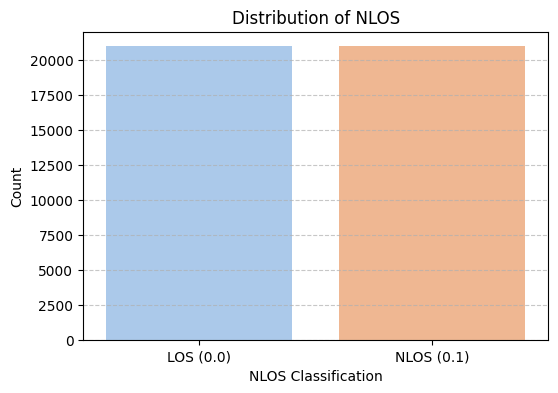

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# count the total in NLOS attribute in the datasets
count_NLOS = df_clean["NLOS"].value_counts()

# visualization to show the distributionfor the 'NLOS' attribute
plt.figure(figsize=(6, 4))
sns.barplot(x=count_NLOS.index, y=count_NLOS.values, palette="pastel")

# Labels and title
plt.xlabel("NLOS Classification")
plt.ylabel("Count")
plt.title("Distribution of NLOS")
plt.xticks([0, 1], ["LOS (0.0)", "NLOS (0.1)"])
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

Shows the distribution of the FP_INDX

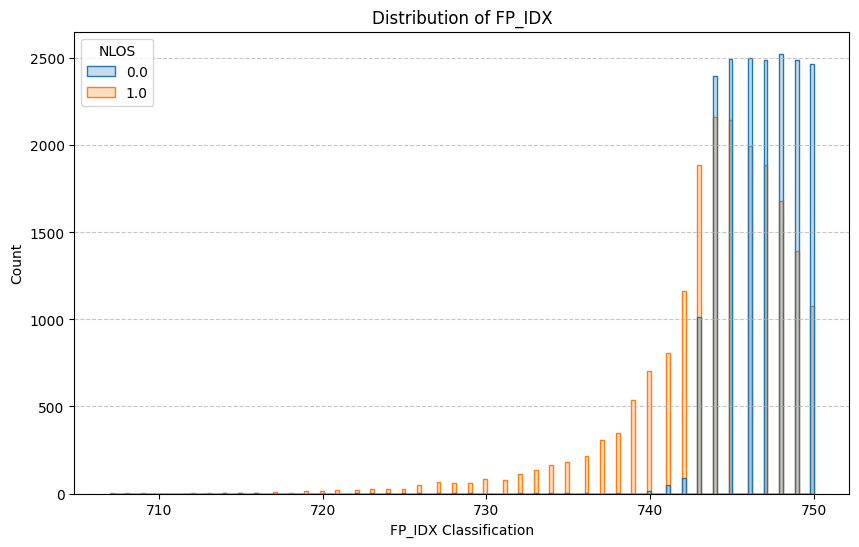

In [ ]:
filtered_data = df_clean[
    df_clean["FP_IDX"] <= 750
]  # set range as it cannot be seen in the graph
plt.figure(figsize=(10, 6))

# Create a count plot for FP_IDX, colored by NLOS
sns.histplot(data=filtered_data, x="FP_IDX", hue="NLOS", kde=False, element="step")

# Labels and title
plt.xlabel("FP_IDX Classification")
plt.ylabel("Count")
plt.title("Distribution of FP_IDX")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

Shows the distribution of the FP_AMP1 , FP_AMP2, FP_AMP3

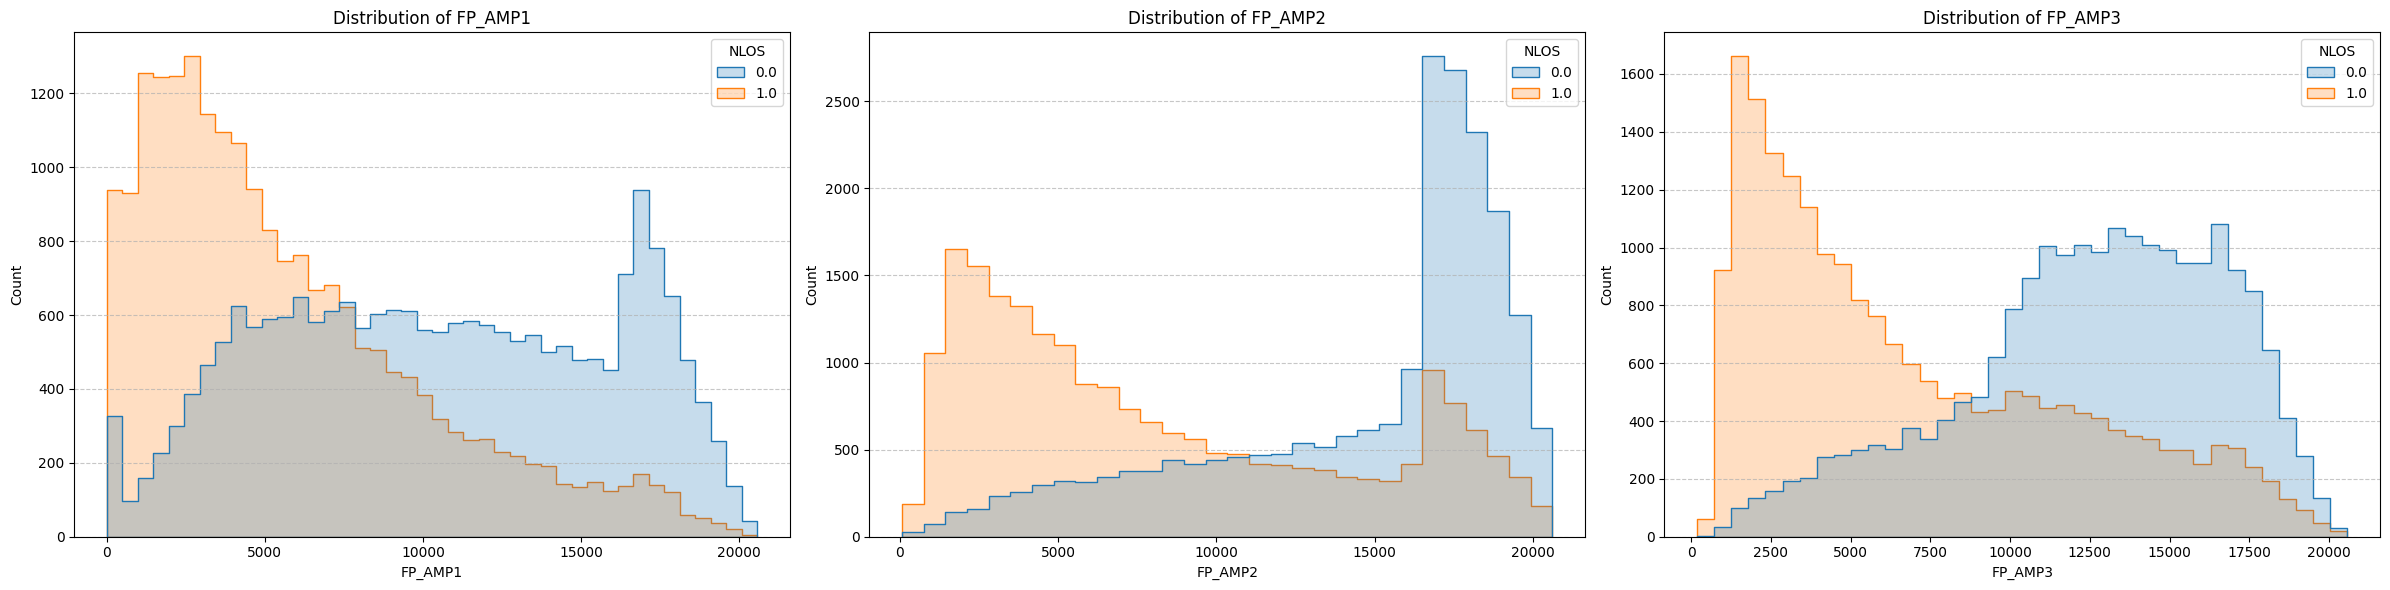

In [65]:
# Create a figure with 4 subplots (1 row, 4 columns)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Plot for FP_AMP1
sns.histplot(
    data=df_clean, x="FP_AMP1", hue="NLOS", kde=False, element="step", ax=axes[0]
)
axes[0].set_xlabel("FP_AMP1")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of FP_AMP1")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Plot for FP_AMP2
sns.histplot(
    data=df_clean, x="FP_AMP2", hue="NLOS", kde=False, element="step", ax=axes[1]
)
axes[1].set_xlabel("FP_AMP2")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of FP_AMP2")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# Plot for FP_AMP3
sns.histplot(
    data=df_clean, x="FP_AMP3", hue="NLOS", kde=False, element="step", ax=axes[2]
)
axes[2].set_xlabel("FP_AMP3")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of FP_AMP3")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()

# Show the combined plot
plt.show()

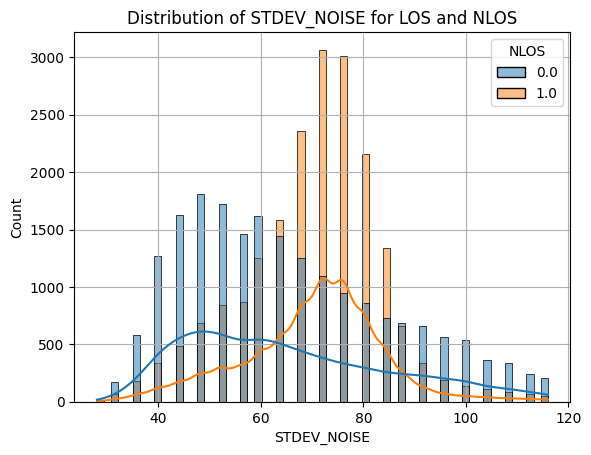

In [67]:
sns.histplot(data=df_clean, x="STDEV_NOISE", hue="NLOS", kde=True)
plt.title("Distribution of STDEV_NOISE for LOS and NLOS")
plt.xlabel("STDEV_NOISE")
plt.ylabel("Count")
plt.grid(True)
plt.show()

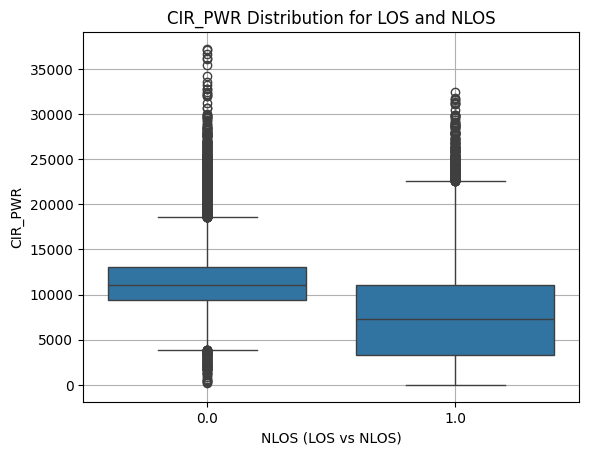

In [68]:
sns.boxplot(data=df_clean, x="NLOS", y="CIR_PWR")
plt.title("CIR_PWR Distribution for LOS and NLOS")
plt.xlabel("NLOS (LOS vs NLOS)")
plt.ylabel("CIR_PWR")
plt.grid(True)
plt.show()

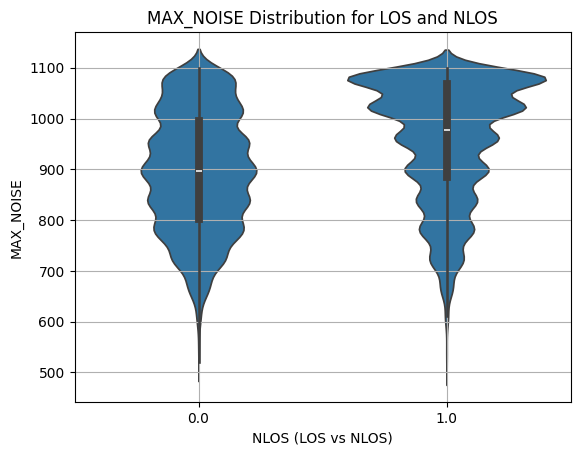

In [99]:
df_clean_filtered = df_clean[(df_clean['MAX_NOISE'] >=500) & (df_clean['MAX_NOISE'] < 1100)]
sns.violinplot(data=df_clean_filtered, x="NLOS", y="MAX_NOISE")
plt.title("MAX_NOISE Distribution for LOS and NLOS")
plt.xlabel("NLOS (LOS vs NLOS)")
plt.ylabel("MAX_NOISE")
plt.grid(True)
plt.show()

AttributeError: QuadMesh.set() got an unexpected keyword argument 'style'

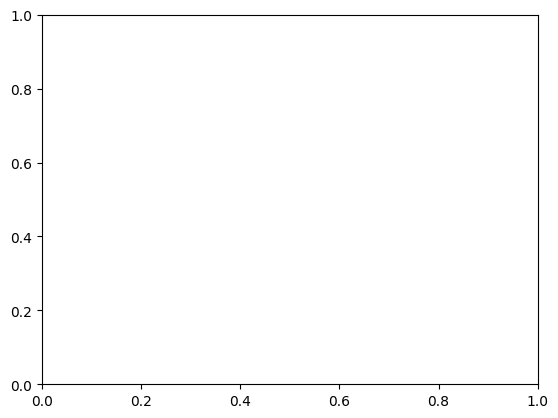

In [100]:
sns.histplot(data=df_clean, x="RANGE", y="CIR_PWR", hue="NLOS", style="NLOS")
plt.xscale('log')  # Apply log scale to RANGE if it spans a large range
plt.yscale('log')  # Apply log scale to CIR_PWR if it's too spread out
plt.title("CIR_PWR vs RANGE for LOS and NLOS")
plt.xlabel("RANGE (Log Scale)")
plt.ylabel("CIR_PWR (Log Scale)")
plt.grid(True)
plt.show()
